<a href="https://colab.research.google.com/github/DebbieArita/DataStructures-Algorithm-Python/blob/main/T2_Data_UPTECH2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTIFICIAL INTELLIGENCE THEME 2
## How AI Learns from Data: K-Means Example
---
In this exercise, we’ll explore one of the simplest ways to understand how AI “learns” — by finding structure in data.
You’ll use K-Means clustering, an unsupervised machine learning method, to see how algorithms detect patterns and groupings without being told what’s right or wrong.

AI systems learn relationships from the data we give them, not from understanding the world itself.
This simple example illustrates why data quality and structure matter so much: a model can only be as good as the information it receives.

**Instructions**
1. Run the setup cell to import the required libraries.
2. Run the main code cell to generate two datasets:
    *  a clean, well-separated dataset,
    *  and a noisy, overlapping one.
3. Observe how K-Means behaves on each, notice the difference in cluster boundaries and color separation.
4. Reflect: What does this tell us about the relationship between data quality and model performance?





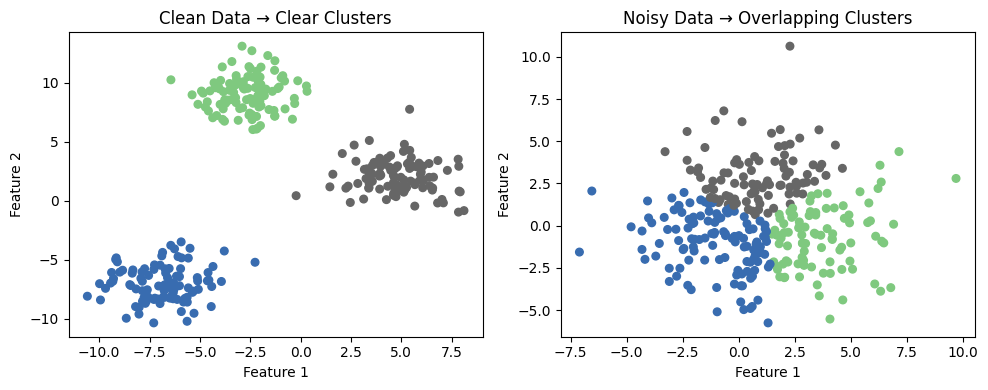

In [ ]:
#Unsupervised Learning Example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate clean, well-separated data
X_clean, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# Generate noisy, overlapping data
X_noisy, _ = make_blobs(n_samples=300, centers=[[0,0],[1,1],[2,0]], cluster_std=2.5, random_state=42)

# Fit KMeans on both
kmeans_clean = KMeans(n_clusters=3, random_state=42).fit(X_clean)
kmeans_noisy = KMeans(n_clusters=3, random_state=42).fit(X_noisy)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Clean data
axes[0].scatter(X_clean[:, 0], X_clean[:, 1], c=kmeans_clean.labels_, cmap='Accent', s=30) # Added s=30
axes[0].set_title("Clean Data → Clear Clusters")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Noisy data
axes[1].scatter(X_noisy[:, 0], X_noisy[:, 1], c=kmeans_noisy.labels_, cmap='Accent', s=30) # Added s=30
axes[1].set_title("Noisy Data → Overlapping Clusters")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

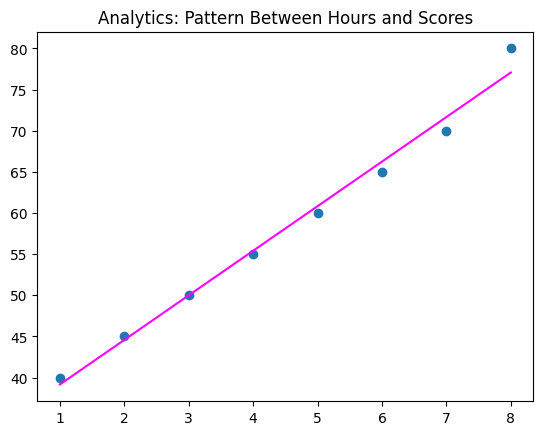

In [ ]:
#Data Analytics Example
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Sample analytics: exploring relationship between study hours and exam scores
data = pd.DataFrame({'hours':[1,2,3,4,5,6,7,8], 'score':[40,45,50,55,60,65,70,80]})
plt.scatter(data['hours'], data['score'])
plt.title("Analytics: Pattern Between Hours and Scores")

# Simple AI model: linear regression learns the relationship
model = LinearRegression().fit(data[['hours']], data['score'])
pred_line = model.predict(data[['hours']])
plt.plot(data['hours'], pred_line, color='magenta')
plt.show()


Test accuracy: 0.921


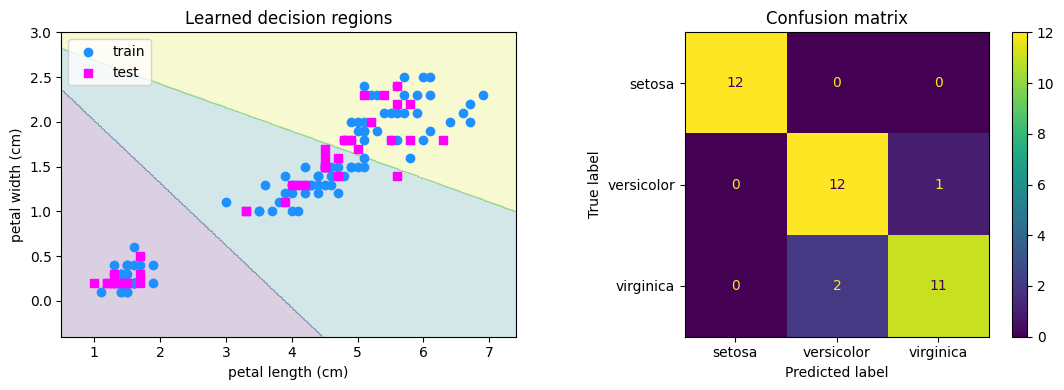

In [ ]:
# AI in one cell: learn → evaluate → visualize (Iris flower classification)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# 1) Load data (use 2 features so we can plot decision regions)
iris = load_iris()
X = iris.data[:, [2, 3]]   # petal length, petal width
y = iris.target
feature_names = [iris.feature_names[i] for i in [2, 3]]
class_names = iris.target_names

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Pipeline: scale → logistic regression
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

# 4) Accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}")

# 5) Decision boundary plot
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Decision regions
ax[0].contourf(xx, yy, Z, alpha=0.2)   # decision regions

# Plot training and test points
ax[0].scatter(X_train[:,0], X_train[:,1], c='dodgerblue', marker='o', label='train')
ax[0].scatter(X_test[:,0],  X_test[:,1],  c='magenta', marker='s', label='test')
ax[0].set_xlabel(feature_names[0])
ax[0].set_ylabel(feature_names[1])
ax[0].set_title("Learned decision regions")
ax[0].legend(loc='best')

# 6) Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, ax=ax[1], cmap=None)
ax[1].set_title("Confusion matrix")

plt.tight_layout()
plt.show()
